In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/baseline_clean.parquet")
df.shape


(2049280, 12)

In [11]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp,apparent_power,power_factor,frequency,thd
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,4.321056,0.975687,50.006094,2.914685
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,5.373490,0.997490,49.979200,3.349644
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,5.365670,1.000000,50.015009,3.881684
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,5.376020,1.000000,50.018811,3.766566
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,3.723744,0.984493,49.960979,4.403303


## Baseline signal behavior

### Voltage over time
Voltage stays within a tight band (~230–250V) over the sampled ~36-hour
window, with smooth drift rather than sudden jumps. This confirms the
grid keeps voltage well-regulated under normal conditions — an important
reference point, since later we'll inject anomalies (sags/swells) that
should look clearly different from this baseline.

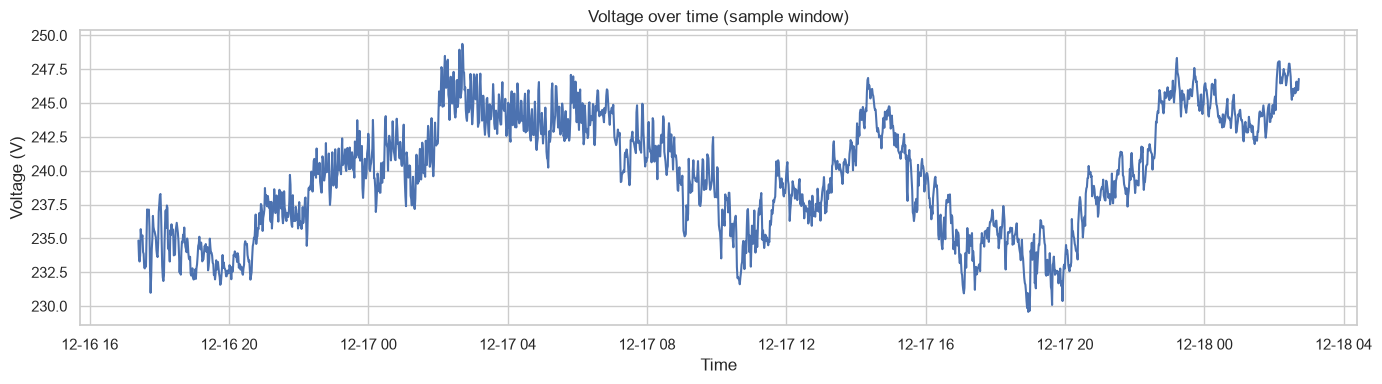

In [12]:
sample = df.iloc[:2000]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["timestamp"], sample["Voltage"])
ax.set_title("Voltage over time (sample window)")
ax.set_xlabel("Time")
ax.set_ylabel("Voltage (V)")
plt.tight_layout()
plt.show()


### Active power over time
Active power is far more volatile than voltage, closely tracking
household appliance activity: rapid on/off cycling (likely a fridge or
heating element), sharp spikes (kettle, washing machine), and long quiet
stretches overnight near ~0.3 kW. This natural cyclical variability is
part of "normal" behavior our detector needs to learn — not every spike
in active power is an anomaly.

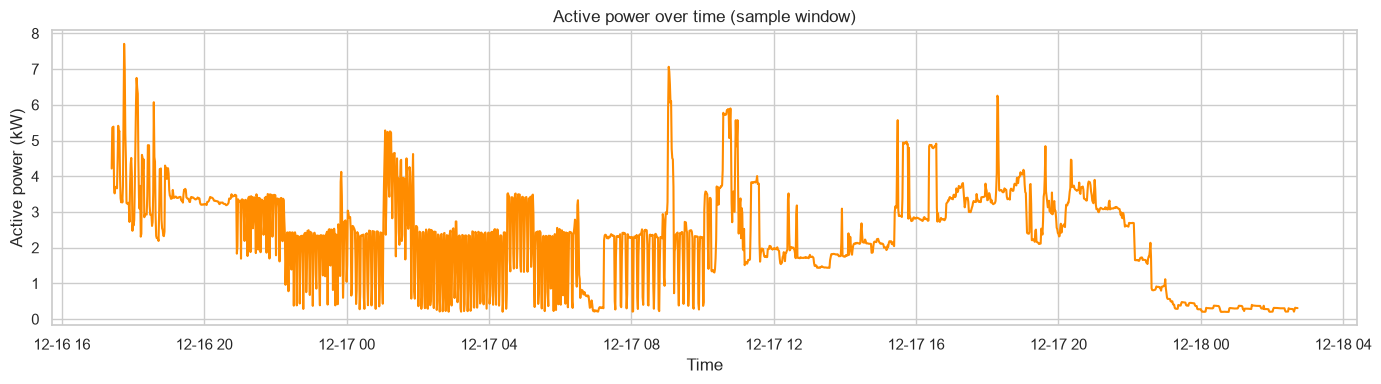

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["timestamp"], sample["Global_active_power"], color="darkorange")
ax.set_title("Active power over time (sample window)")
ax.set_xlabel("Time")
ax.set_ylabel("Active power (kW)")
plt.tight_layout()
plt.show()

### Signal distributions
- **Voltage**: roughly bell-shaped, centered around ~240V — consistent
  with the tight regulation seen in the time-series plot.
- **Active power / current**: right-skewed, with most readings low and
  a long tail of rarer high-usage periods — typical of household
  consumption patterns.
- **Power factor**: concentrated near 1.0 with a tail down to ~0.35,
  matching expectations — power factor drops during low-load periods
  when reactive power dominates relative to the small active power draw.

Together, these confirm the baseline dataset is clean and behaves
realistically, giving us a solid foundation to build synthetic anomalies
on top of in the next step.

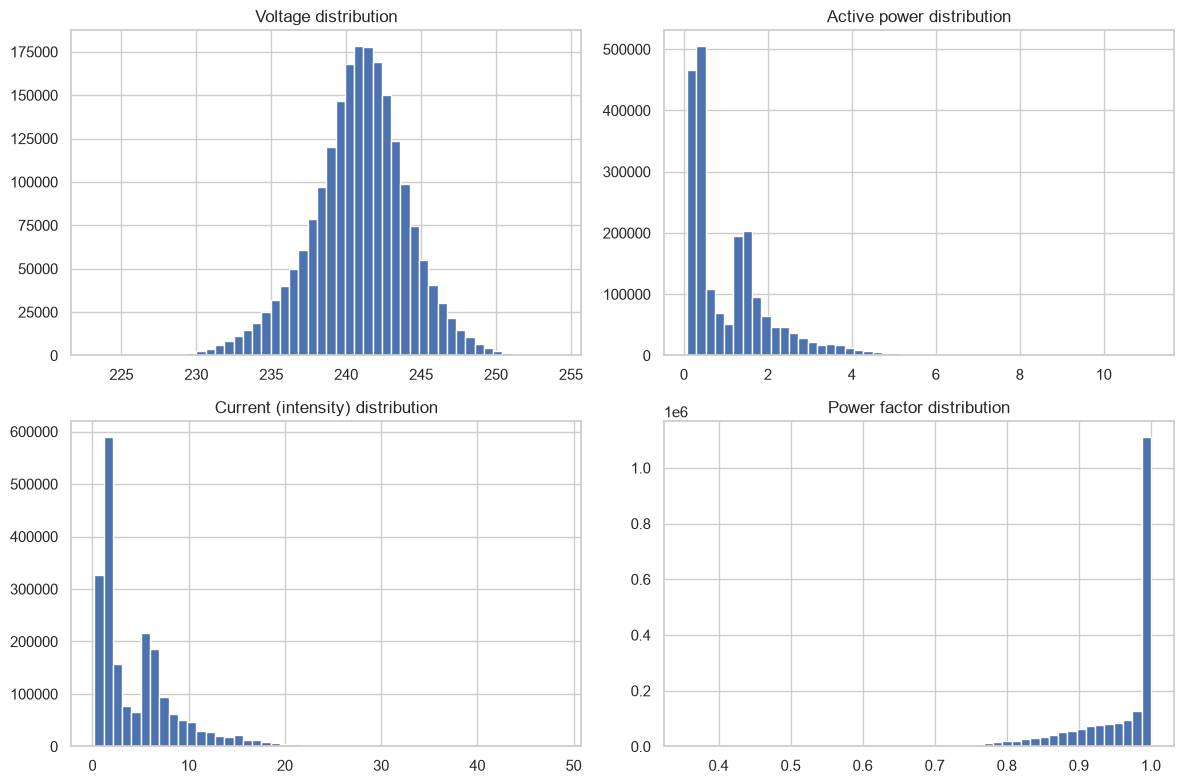

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df["Voltage"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Voltage distribution")

df["Global_active_power"].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Active power distribution")

df["Global_intensity"].hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Current (intensity) distribution")

df["power_factor"].hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Power factor distribution")

plt.tight_layout()
plt.show()